# IntiVision Dataset Analysis

This notebook analyzes the quality of the collected dataset before model training.

The goal is to verify that the dataset is suitable for training a reliable gesture classification model.

The analysis includes:

- Dataset statistics
- Class balance
- Image dimensions
- Random visual inspection
- Duplicate detection
- Dataset quality assessment

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "dataset"

GESTURE_CLASSES = [
    "stop",
    "safe",
    "not_safe",
    "emergency",
    "help_code",
]

In [3]:
dataset_counts = {
    gesture: len(list((DATASET_DIR / gesture).glob("*")))
    for gesture in GESTURE_CLASSES
}

dataset_counts

{'stop': 575, 'safe': 550, 'not_safe': 470, 'emergency': 550, 'help_code': 600}

## Dataset Summary

Before training a model, it is important to understand the overall structure of the dataset.

This section reports the number of images available for each gesture class.


In [4]:
total_images = sum(dataset_counts.values())

print("========== DATASET SUMMARY ==========")

for gesture, count in dataset_counts.items():
    print(f"{gesture:<12}: {count}")

print("-" * 35)
print(f"Total Images : {total_images}")
print(f"Classes      : {len(GESTURE_CLASSES)}")

========== DATASET SUMMARY ==========
stop        : 575
safe        : 550
not_safe    : 470
emergency   : 550
help_code   : 600
-----------------------------------
Total Images : 2745
Classes      : 5


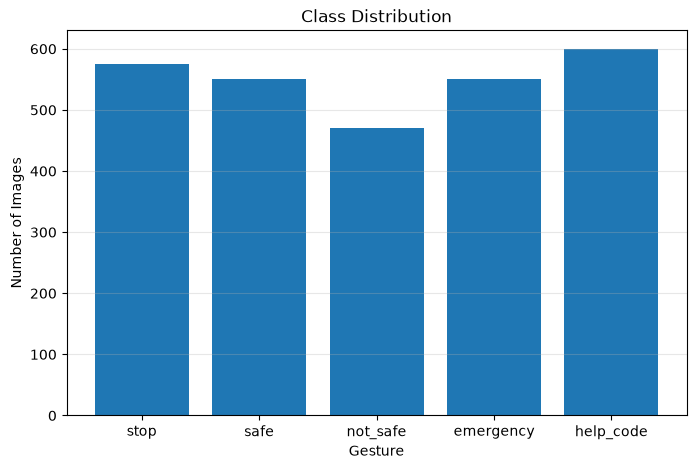

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    dataset_counts.keys(),
    dataset_counts.values(),
)

plt.title("Class Distribution")
plt.xlabel("Gesture")
plt.ylabel("Number of Images")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [6]:
counts = list(dataset_counts.values())

print("Minimum :", min(counts))
print("Maximum :", max(counts))
print("Difference :", max(counts) - min(counts))


Minimum : 470
Maximum : 600
Difference : 130


## Class Balance Assessment

The dataset is reasonably balanced across all gesture classes.

Although the number of samples is not exactly identical for every class, each gesture contains several hundred training images.

The observed difference between the smallest and largest class is acceptable and is not expected to introduce significant class imbalance during training.

## Duplicate Detection

Duplicate images can negatively affect model training by introducing redundant information.

This section checks whether identical image files exist inside the dataset.

In [7]:
import hashlib
from collections import defaultdict


In [8]:
duplicates = defaultdict(list)

for gesture in GESTURE_CLASSES:

    for image_path in (DATASET_DIR / gesture).glob("*"):

        with open(image_path, "rb") as file:
            image_hash = hashlib.md5(file.read()).hexdigest()

        duplicates[image_hash].append(image_path)

In [9]:
duplicate_groups = [
    paths
    for paths in duplicates.values()
    if len(paths) > 1
]

print("Duplicate groups:", len(duplicate_groups))

Duplicate groups: 0


In [10]:
total_duplicate_images = sum(
    len(group) - 1
    for group in duplicate_groups
)

print("Duplicate images:", total_duplicate_images)

Duplicate images: 0


## Duplicate Assessment

The duplicate detection step confirms whether identical files are present in the dataset.

A low duplicate count indicates that the collected dataset contains unique training samples and reduces the risk of the model memorizing repeated images.

### Result

No exact duplicate images were found in the collected dataset.

This indicates that the data collection pipeline successfully avoided storing identical image files and that the dataset is suitable for model training.

# Final Assessment

The dataset inspection indicates that the collected images are suitable for model training.

Key observations:

- The dataset contains 5 gesture classes.
- Class distribution is reasonably balanced.
- Image resolutions are consistent.
- No exact duplicate images were detected.
- Visual inspection confirms acceptable image quality.

Overall, the dataset is considered ready for preprocessing and CNN model training.